In [ ]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn catboost matplotlib

In [ ]:
import sys
from pathlib import Path

# adiciona a pasta src ao sys.path
SRC_DIR = Path().resolve().parent  # .../src
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

In [ ]:
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from catboost import CatBoostClassifier

from utils.constants import *

/home/gabriel/Documents/UFRGS/dengue-severity-prediction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv("../data/3_gold/dataset-processed-gb.csv")
X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

X_coarse = X_train.copy()
y_coarse = y_train.copy()
y_coarse = y_coarse.map(COARSE_LABEL_MAP)

high_risk_mask = y_train.isin([1, 2])
X_fine = X_train[high_risk_mask].copy()
y_fine = y_train[high_risk_mask].copy()
y_fine = y_fine.map(FINE_LABEL_MAP)

class_counts_coarse = Counter(y_coarse)
class_counts_fine = Counter(y_fine)

print("=== Coarse Data ===")
for class_idx, count in class_counts_coarse.items():
    print(f"Number of '{TARGET_NAMES_COARSE[class_idx]}' examples: {count}")

print("\n=== Fine Data ===")
for class_idx, count in class_counts_fine.items():
    print(f"Number of '{TARGET_NAMES_FINE[class_idx]}' examples: {count}")

=== Coarse Data ===
Number of 'low_risk' examples: 359346
Number of 'high_risk' examples: 252602

=== Fine Data ===
Number of 'alarm' examples: 228273
Number of 'severe' examples: 24329


In [ ]:
params_cat_coarse = {
    'iterations': 2000,
    'learning_rate': 0.05,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'auto_class_weights': 'Balanced',
    'early_stopping_rounds': 10,
    'random_state': RANDOM_STATE,
    'cat_features': list(CATEGORICAL_COLUMNS)
}
params_cat_fine = {
    'iterations': 2000,
    'learning_rate': 0.03,
    'depth': 8,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',         
    'auto_class_weights': 'Balanced',
    'early_stopping_rounds': 10,
    'random_state': RANDOM_STATE,
    'cat_features': list(CATEGORICAL_COLUMNS)
}

In [ ]:
def get_catboost_models():
    model_coarse = CatBoostClassifier(**params_cat_coarse)
    model_fine = CatBoostClassifier(**params_cat_fine)
    return model_coarse, model_fine


def train_hierarchical_catboost(X_coarse, y_coarse, X_fine, y_fine):
    X_train_coarse, X_val_coarse, y_train_coarse, y_val_coarse = train_test_split(
        X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
    )
    X_train_fine, X_val_fine, y_train_fine, y_val_fine = train_test_split(
        X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
    )
    model_coarse, model_fine = get_catboost_models()
    
    print("Training Coarse Model...")
    model_coarse.fit(
        X_train_coarse, y_train_coarse,
        eval_set=(X_val_coarse, y_val_coarse),
        use_best_model=True
    )

    print("Training Fine Model...")
    model_fine.fit(
        X_train_fine, y_train_fine,
        eval_set=(X_val_fine, y_val_fine) if len(X_val_fine) > 0 else None,
        use_best_model=True if len(X_val_fine) > 0 else False
    )
    return model_coarse, model_fine


def predict_soft_cascade(
        model_coarse, model_fine, X, y, 
        coarse_offset=0.1, weight_low=0.9, weight_alarm=1.0, weight_severe=1.1
    ):
    # Get Probabilities from Coarse
    probs_coarse = model_coarse.predict_proba(X)
    p_high_risk = (probs_coarse[:, 1] + coarse_offset).clip(0.0, 1.0)
    
    # Get Probabilities from Fine
    probs_fine = model_fine.predict_proba(X) 
    p_severe_given_high = probs_fine[:, 1] # P(Severe | High)
        
    # P(Severe) = P(High) * P(Severe | High)
    p_severe_global = p_high_risk * p_severe_given_high
    
    # P(Alarm) = P(High) * (1 - P(Severe | High))
    p_alarm_global = p_high_risk * (1 - p_severe_given_high)
    
    # P(Low) = 1 - P(High)
    p_low_global = 1.0 - p_high_risk
    
    final_probs = np.vstack([p_low_global, p_alarm_global, p_severe_global]).T

    weights = np.array([weight_low, weight_alarm, weight_severe])
    weighted_probs = final_probs * weights
    final_preds = np.argmax(weighted_probs, axis=1)

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds


def predict_hard_cascade(
    model_coarse, model_fine, X, y, 
    threshold_coarse=0.4, threshold_fine=0.5
):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X)[:, 1]
    
    preds_coarse = (probs_coarse >= threshold_coarse).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        probs_fine_local = model_fine.predict_proba(X_high_risk)[:, 1]
        preds_fine_local = (probs_fine_local >= threshold_fine).astype(int)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds

In [ ]:
model_coarse, model_fine = train_hierarchical_catboost(X_coarse, y_coarse, X_fine, y_fine)

Training Coarse Model...
0:	test: 0.7646858	best: 0.7646858 (0)	total: 215ms	remaining: 7m 9s
1:	test: 0.7721951	best: 0.7721951 (1)	total: 372ms	remaining: 6m 11s
2:	test: 0.7757133	best: 0.7757133 (2)	total: 477ms	remaining: 5m 17s
3:	test: 0.7813474	best: 0.7813474 (3)	total: 635ms	remaining: 5m 16s
4:	test: 0.7815463	best: 0.7815463 (4)	total: 801ms	remaining: 5m 19s
5:	test: 0.7833952	best: 0.7833952 (5)	total: 917ms	remaining: 5m 4s
6:	test: 0.7837400	best: 0.7837400 (6)	total: 1.06s	remaining: 5m 2s
7:	test: 0.7845711	best: 0.7845711 (7)	total: 1.21s	remaining: 5m
8:	test: 0.7859199	best: 0.7859199 (8)	total: 1.31s	remaining: 4m 50s
9:	test: 0.7901585	best: 0.7901585 (9)	total: 1.45s	remaining: 4m 48s
10:	test: 0.7913739	best: 0.7913739 (10)	total: 1.59s	remaining: 4m 47s
11:	test: 0.7929098	best: 0.7929098 (11)	total: 1.72s	remaining: 4m 44s
12:	test: 0.7937440	best: 0.7937440 (12)	total: 1.87s	remaining: 4m 46s
13:	test: 0.7952204	best: 0.7952204 (13)	total: 2.03s	remaining: 4

In [ ]:
f1_soft, preds_soft = predict_soft_cascade(
    model_coarse, model_fine, X_test, y_test,
    coarse_offset=0.1, weight_low=0.9, weight_alarm=1.0, weight_severe=1.1
)
f1_hard, preds_hard = predict_hard_cascade(
    model_coarse, model_fine, X_test, y_test,
    threshold_coarse=0.4, threshold_fine=0.5
)

              precision    recall  f1-score   support

    Low Risk       0.82      0.75      0.78     63414
       Alarm       0.62      0.50      0.56     40283
      Severe       0.14      0.59      0.23      4294

    accuracy                           0.65    107991
   macro avg       0.53      0.62      0.52    107991
weighted avg       0.72      0.65      0.68    107991

              precision    recall  f1-score   support

    Low Risk       0.85      0.67      0.75     63414
       Alarm       0.58      0.59      0.58     40283
      Severe       0.15      0.58      0.23      4294

    accuracy                           0.64    107991
   macro avg       0.52      0.61      0.52    107991
weighted avg       0.72      0.64      0.67    107991



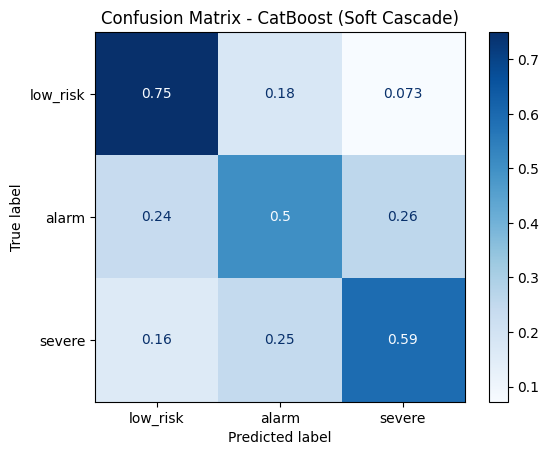

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_soft, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - CatBoost (Soft Cascade)")
plt.show()

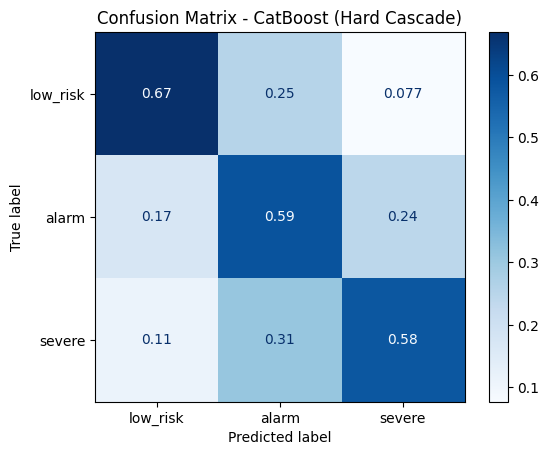

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_hard, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - CatBoost (Hard Cascade)")
plt.show()